# Marketing Campaign Performance Dashboard

## Business Understanding

Perusahaan menjalankan berbagai kampanye pemasaran melalui beberapa channel untuk meningkatkan penjualan dan konversi pelanggan. Namun, manajemen belum mengetahui campaign mana yang memberikan performa terbaik dan channel mana yang paling efektif.

Melalui dashboard ini, diharapkan stakeholder dapat memantau performa campaign secara interaktif sehingga dapat mengambil keputusan pemasaran dengan lebih cepat dan berbasis data.

## Dataset Description

Dataset yang digunakan dalam proyek ini adalah [**Marketing Campaign Performance Dataset**](https://www.kaggle.com/datasets/manishabhatt22/marketing-campaign-performance-dataset?utm_source=chatgpt.com) yang diperoleh dari Kaggle. Dataset ini berisi informasi mengenai performa berbagai kampanye pemasaran yang dilakukan oleh beberapa perusahaan dengan berbagai jenis campaign, target audience, channel marketing, lokasi, dan periode waktu.

Data ini mencakup berbagai metrik penting dalam evaluasi pemasaran, seperti Conversion Rate, ROI (Return on Investment), Clicks, Impressions, Engagement Score, serta Acquisition Cost. Dengan informasi tersebut, dataset dapat digunakan untuk menganalisis efektivitas strategi pemasaran dan mendukung pengambilan keputusan berbasis data.

Pada proyek ini, dataset digunakan untuk melakukan proses data cleaning, exploratory data analysis (EDA), serta membangun interactive dashboard menggunakan Power BI guna memperoleh insight mengenai performa campaign dari berbagai perspektif.

# 1. Import Library

In [20]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

# 2. Load Dataset & Data Understanding

In [21]:
df = pd.read_csv("../data/raw/marketing_campaign_dataset.csv")
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [22]:
df.shape

(200000, 16)

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  str    
 2   Campaign_Type     200000 non-null  str    
 3   Target_Audience   200000 non-null  str    
 4   Duration          200000 non-null  str    
 5   Channel_Used      200000 non-null  str    
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  str    
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  str    
 10  Language          200000 non-null  str    
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  str    
 15  Date              200000 non-null  str    
dtypes: float64(2), int64(4), str(10

In [24]:
df.describe(include='all')

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
count,200000.000000,200000,200000,200000,200000,200000,200000.000000,200000,200000.000000,200000,200000,200000.000000,200000.000000,200000.000000,200000,200000
unique,NaN,5,5,5,4,6,NaN,15001,NaN,5,5,NaN,NaN,NaN,5,365
top,NaN,TechCorp,Influencer,Men 18-24,30 days,Email,NaN,"$16,578.00",NaN,Miami,Mandarin,NaN,NaN,NaN,Foodies,2021-01-01
freq,NaN,40237,40169,40258,50255,33599,NaN,32,NaN,40269,40255,NaN,NaN,NaN,40208,548
mean,100000.500000,NaN,NaN,NaN,NaN,NaN,0.080070,NaN,5.002438,NaN,NaN,549.772030,5507.301520,5.494710,NaN,NaN
std,57735.171256,NaN,NaN,NaN,NaN,NaN,0.040602,NaN,1.734488,NaN,NaN,260.019056,2596.864286,2.872581,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,0.010000,NaN,2.000000,NaN,NaN,100.000000,1000.000000,1.000000,NaN,NaN
25%,50000.750000,NaN,NaN,NaN,NaN,NaN,0.050000,NaN,3.500000,NaN,NaN,325.000000,3266.000000,3.000000,NaN,NaN
50%,100000.500000,NaN,NaN,NaN,NaN,NaN,0.080000,NaN,5.010000,NaN,NaN,550.000000,5517.500000,5.000000,NaN,NaN
75%,150000.250000,NaN,NaN,NaN,NaN,NaN,0.120000,NaN,6.510000,NaN,NaN,775.000000,7753.000000,8.000000,NaN,NaN


# 3. Data Cleaning & Preprocessing

## 3.1 Missing Values

In [25]:
df.isnull().sum()

Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

## 3.2 Duplicate Data

In [26]:
df.duplicated().sum()

np.int64(0)

## 3.3 Data Type

In [27]:
df.dtypes

Campaign_ID           int64
Company                 str
Campaign_Type           str
Target_Audience         str
Duration                str
Channel_Used            str
Conversion_Rate     float64
Acquisition_Cost        str
ROI                 float64
Location                str
Language                str
Clicks                int64
Impressions           int64
Engagement_Score      int64
Customer_Segment        str
Date                    str
dtype: object

In [28]:
df["Date"] = pd.to_datetime(df["Date"])
df['Date'].dtype

dtype('<M8[us]')

Kolom Date diubah ke format datetime agar dapat digunakan untuk analisis tren pada dashboard.

## 3.4 Checking Categorical Values

In [29]:
print("Unique Channels:", df['Channel_Used'].unique())
print("Unique Campaign Types:", df['Campaign_Type'].unique())
print("Unique Locations:", df['Location'].unique())

Unique Channels: <StringArray>
['Google Ads', 'YouTube', 'Instagram', 'Website', 'Facebook', 'Email']
Length: 6, dtype: str
Unique Campaign Types: <StringArray>
['Email', 'Influencer', 'Display', 'Search', 'Social Media']
Length: 5, dtype: str
Unique Locations: <StringArray>
['Chicago', 'New York', 'Los Angeles', 'Miami', 'Houston']
Length: 5, dtype: str


Dataset terdiri dari 200000 baris dan 16 kolom yang berisi informasi mengenai campaign pemasaran, channel, conversion rate, ROI, engagement, dan metrik lainnya. Tidak ditemukan missing value maupun duplicate data. Selain itu, tipe data pada kolom tanggal telah disesuaikan agar mendukung analisis berbasis waktu.

### Export Clean Data

In [30]:
df.to_csv("../data/processed/marketing_campaign_clean.csv", index=False)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       200000 non-null  int64         
 1   Company           200000 non-null  str           
 2   Campaign_Type     200000 non-null  str           
 3   Target_Audience   200000 non-null  str           
 4   Duration          200000 non-null  str           
 5   Channel_Used      200000 non-null  str           
 6   Conversion_Rate   200000 non-null  float64       
 7   Acquisition_Cost  200000 non-null  str           
 8   ROI               200000 non-null  float64       
 9   Location          200000 non-null  str           
 10  Language          200000 non-null  str           
 11  Clicks            200000 non-null  int64         
 12  Impressions       200000 non-null  int64         
 13  Engagement_Score  200000 non-null  int64         
 14  Customer_Segmen

In [33]:
df["ROI"].describe()

count    200000.000000
mean          5.002438
std           1.734488
min           2.000000
25%           3.500000
50%           5.010000
75%           6.510000
max           8.000000
Name: ROI, dtype: float64

# 4. Key Performance Indicators (KPI) Selection
Beberapa KPI utama yang akan dihitung dan ditampilkan meliputi:

*   **Total Campaigns:** Jumlah keseluruhan campaign marketing yang dijalankan.
*   **Average ROI (Return on Investment):** Rata-rata tingkat pengembalian investasi dari seluruh campaign untuk mengukur profitabilitas.
*   **Average Conversion Rate:** Rata-rata persentase audiens yang melakukan aksi/transaksi setelah melihat campaign.
*   **Total Clicks:** Akumulasi jumlah klik yang didapatkan dari seluruh iklan.
*   **Total Impressions:** Total berapa kali iklan ditayangkan atau dilihat oleh audiens.
*   **Average Engagement Score:** Rata-rata tingkat interaksi audiens terhadap campaign yang dijalankan.

# 5. Dashboard Planning & Business Questions
Agar dashboard tidak sekadar menjadi grafik biasa, visualisasi akan dirancang secara spesifik untuk menjawab beberapa pertanyaan bisnis (*business questions*) seperti berikut:

1.  **Campaign Type Performance:** Jenis campaign apa yang memberikan rata-rata ROI tertinggi dan paling efisien?
2.  **Channel Effectiveness:** Saluran marketing (*marketing channel*) mana yang menghasilkan *Conversion Rate* terbaik?
3.  **Company Analysis:** Perusahaan (*Company*) mana yang mengeksekusi campaign dengan performa paling optimal?
4.  **Trend Over Time:** Bagaimana tren performa KPI marketing (ROI dan Clicks) bergerak dari waktu ke waktu?
5.  **Audience Engagement:** Kelompok *Target Audience* mana yang memberikan respon dan *Engagement Score* paling tinggi?
6.  **Geographic Performance:** Apakah terdapat perbedaan performa campaign atau ROI yang signifikan berdasarkan lokasi geografis?

# 6. Dashboard Overview

Setelah proses pembersihan data dan analisis eksploratif selesai dilakukan, data kemudian divisualisasikan menggunakan Microsoft Power BI.

Dashboard ini dirancang untuk membantu pengguna memantau performa campaign marketing melalui beberapa Key Performance Indicator (KPI) dan visualisasi interaktif sehingga dapat mendukung proses pengambilan keputusan berbasis data.

Dashboard terdiri dari beberapa komponen utama, yaitu:

- KPI Cards
- Average ROI berdasarkan Campaign Type
- Average Conversion Rate berdasarkan Channel
- Tren Average ROI dari waktu ke waktu
- Average ROI berdasarkan Location
- Interactive Slicer (Campaign Type, Channel, dan Location)

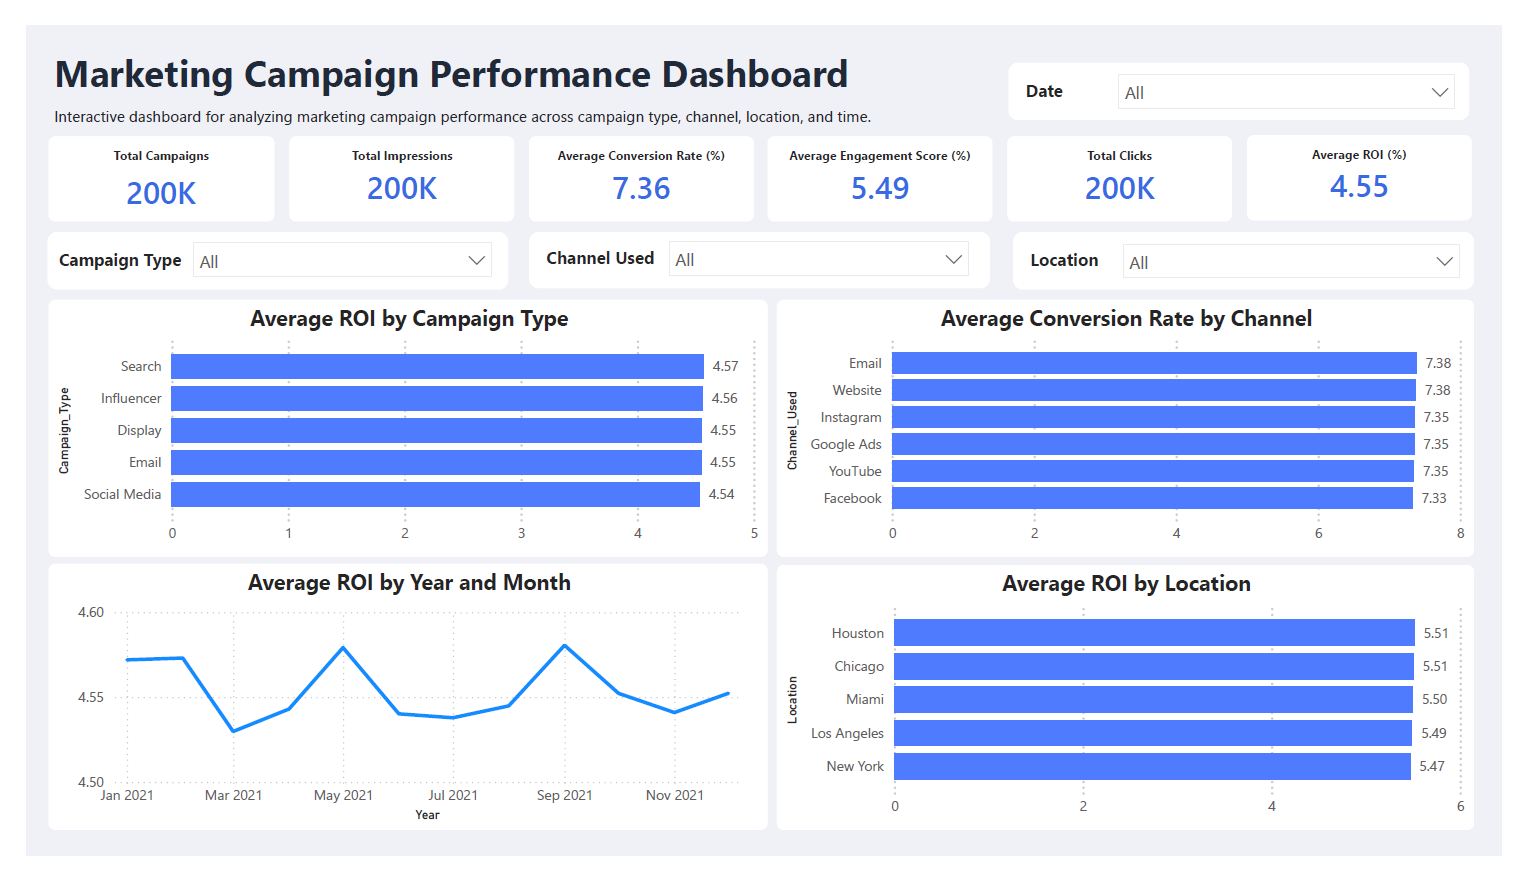

In [2]:
from IPython.display import Image, display

display(Image("../images/Marketing_Dashboard.png", width=1200))

# Business Insights

### 1. Campaign Type Performance

Berdasarkan hasil analisis, **Search Campaign memiliki rata-rata Return on Investment (ROI) tertinggi** dibandingkan jenis campaign lainnya. Meskipun demikian, selisih nilai ROI antar campaign relatif kecil sehingga seluruh jenis campaign menunjukkan performa yang cukup konsisten. Hal ini mengindikasikan bahwa tidak ada satu jenis campaign yang mendominasi secara signifikan dalam menghasilkan ROI.

### 2. Channel Effectiveness

Hasil visualisasi menunjukkan bahwa **Email merupakan channel marketing dengan Conversion Rate rata-rata tertinggi** dibandingkan channel lainnya. Meskipun perbedaannya tidak terlalu besar, Email dapat dianggap sebagai channel yang paling efektif dalam menghasilkan konversi pada dataset ini.

### 3. Company Analysis

Berdasarkan hasil eksplorasi data, **performa campaign antar perusahaan relatif seragam**. Tidak terdapat perusahaan yang secara konsisten memiliki performa jauh lebih baik dibandingkan perusahaan lainnya berdasarkan metrik yang dianalisis. Oleh karena itu, analisis lebih difokuskan pada campaign, channel, lokasi, dan waktu dibandingkan perbandingan antar perusahaan.

### 4. Trend Over Time

Visualisasi tren menunjukkan bahwa nilai Average ROI relatif stabil sepanjang periode pengamatan. Tidak terlihat adanya peningkatan maupun penurunan yang signifikan dari bulan ke bulan, sehingga dapat disimpulkan bahwa **performa campaign cenderung konsisten selama periode tersebut.**

### 5. Audience Engagement

Berdasarkan hasil analisis, **rata-rata Engagement Score pada setiap kelompok Target Audience memiliki nilai yang hampir serupa.** Hal ini menunjukkan bahwa seluruh kelompok audiens memberikan tingkat keterlibatan yang relatif seimbang terhadap campaign yang dijalankan, sehingga belum terdapat segmen audiens yang menunjukkan performa jauh lebih unggul.

### 6. Geographic Performance

Analisis berdasarkan lokasi menunjukkan bahwa rata-rata ROI pada setiap kota memiliki perbedaan yang relatif kecil. Dengan demikian, **lokasi geografis belum menunjukkan pengaruh yang signifikan terhadap keberhasilan campaign pada dataset ini**. Faktor lain seperti jenis campaign atau channel marketing kemungkinan memiliki pengaruh yang lebih besar terhadap performa campaign.

# Business Recommendations

1. Mempertahankan dan mengoptimalkan Search Campaign karena memiliki rata-rata ROI tertinggi.
2. Meningkatkan pemanfaatan Email Marketing sebagai channel utama karena menghasilkan Conversion Rate terbaik.
3. Melakukan evaluasi terhadap faktor lain seperti Acquisition Cost dan Customer Segment, mengingat perbedaan performa antar kategori pada dataset ini relatif kecil.